# 01. Python, PyTorch y Tensores

## Clase práctica guiada
**Aprendizaje Profundo — UNSAM**

Bienvenidas y bienvenidos. En esta práctica vamos a tomar las ideas teóricas de la clase y convertirlas en intuición visual y código reproducible.

### Objetivos de aprendizaje
- Entender qué es un tensor desde ejemplos concretos: 0D, 1D, 2D y 3D.
- Ver cómo PyTorch y NumPy se relacionan entre sí y cuándo comparten memoria.
- Comprender cómo `Autograd` calcula derivadas automáticamente.
- Construir y entrenar una neurona lineal simple paso a paso.

## Cómo trabajar este notebook

La idea no es correr todo mecánicamente, sino **leer, predecir, ejecutar y observar**.

En cada bloque vamos a responder una pregunta distinta:
1. ¿Qué representa un tensor y cómo se organiza por dimensiones?
2. ¿Cómo calcula PyTorch derivadas de forma automática?
3. ¿Cómo conectamos datos, lotes (`batches`) y un modelo entrenable?

> Consejo didáctico: antes de ejecutar cada celda, intentá anticipar qué forma tendrá cada tensor y qué debería mostrar cada gráfico.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

np.random.seed(7)
torch.manual_seed(7)

print(f"PyTorch: {torch.__version__}")
print(f"NumPy: {np.__version__}")
print(f"CUDA disponible: {torch.cuda.is_available()}")

PyTorch: 2.10.0+cu128
NumPy: 2.2.6
CUDA disponible: True


## 1. Core Concepts: Tensores

Un tensor es una estructura que almacena números en una o más dimensiones.

La forma más útil de pensarlo es esta:
- **0D**: un único número → escalar.
- **1D**: una lista ordenada de números → vector.
- **2D**: una grilla de números → matriz.
- **3D**: varias matrices apiladas → por ejemplo, una imagen RGB con canales, alto y ancho.

In [2]:
def describe_tensor(name, tensor):
    shape = tuple(tensor.shape) if tensor.ndim > 0 else ()
    print(f"{name:>10} | ndim = {tensor.ndim} | shape = {shape} | dtype = {tensor.dtype}")
    print(tensor)
    print("-" * 70)

# 0D: escalar
scalar = torch.tensor(7.0)

# 1D: vector
vector = torch.tensor([1.0, 3.0, 5.0, 7.0])

# 2D: matriz
matrix = torch.tensor([[1.0, 2.0, 3.0],
                       [4.0, 5.0, 6.0]])

# 3D: imagen RGB sintética con forma (canales, alto, ancho)
red_channel = torch.linspace(0.2, 1.0, 16).reshape(4, 4)
green_channel = red_channel.flip(0)
blue_channel = red_channel.flip(1)
image = torch.stack([red_channel, green_channel, blue_channel], dim=0)

for name, tensor in [("Escalar", scalar), ("Vector", vector), ("Matriz", matrix), ("Imagen", image)]:
    describe_tensor(name, tensor)

   Escalar | ndim = 0 | shape = () | dtype = torch.float32
tensor(7.)
----------------------------------------------------------------------
    Vector | ndim = 1 | shape = (4,) | dtype = torch.float32
tensor([1., 3., 5., 7.])
----------------------------------------------------------------------
    Matriz | ndim = 2 | shape = (2, 3) | dtype = torch.float32
tensor([[1., 2., 3.],
        [4., 5., 6.]])
----------------------------------------------------------------------
    Imagen | ndim = 3 | shape = (3, 4, 4) | dtype = torch.float32
tensor([[[0.2000, 0.2533, 0.3067, 0.3600],
         [0.4133, 0.4667, 0.5200, 0.5733],
         [0.6267, 0.6800, 0.7333, 0.7867],
         [0.8400, 0.8933, 0.9467, 1.0000]],

        [[0.8400, 0.8933, 0.9467, 1.0000],
         [0.6267, 0.6800, 0.7333, 0.7867],
         [0.4133, 0.4667, 0.5200, 0.5733],
         [0.2000, 0.2533, 0.3067, 0.3600]],

        [[0.3600, 0.3067, 0.2533, 0.2000],
         [0.5733, 0.5200, 0.4667, 0.4133],
         [0.7867, 0.733

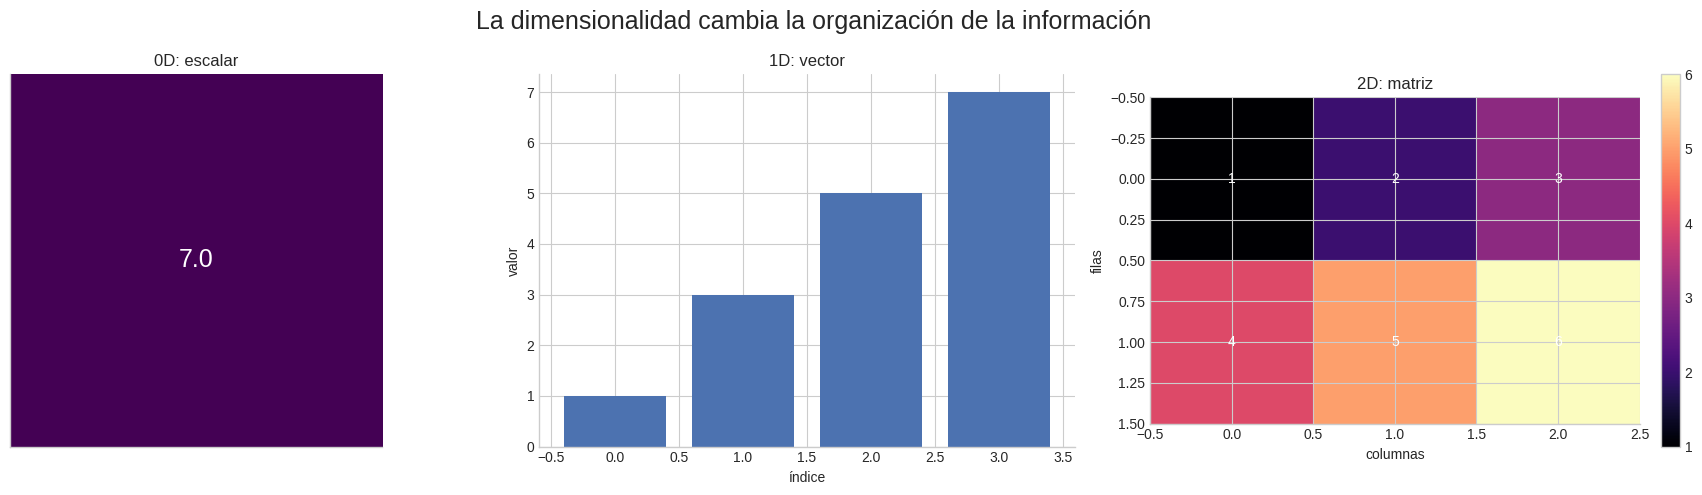

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Escalar: un solo valor
axes[0].imshow([[scalar.item()]], cmap="viridis", aspect="equal")
axes[0].text(0, 0, f"{scalar.item():.1f}", ha="center", va="center", color="white", fontsize=18)
axes[0].set_title("0D: escalar")
axes[0].set_xticks([])
axes[0].set_yticks([])

# Vector: una secuencia ordenada
axes[1].bar(np.arange(vector.numel()), vector.numpy(), color="#4C72B0")
axes[1].set_title("1D: vector")
axes[1].set_xlabel("índice")
axes[1].set_ylabel("valor")

# Matriz: una grilla de números
im = axes[2].imshow(matrix.numpy(), cmap="magma")
axes[2].set_title("2D: matriz")
axes[2].set_xlabel("columnas")
axes[2].set_ylabel("filas")
for row in range(matrix.shape[0]):
    for col in range(matrix.shape[1]):
        axes[2].text(col, row, f"{matrix[row, col].item():.0f}", ha="center", va="center", color="white")

fig.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)
fig.suptitle("La dimensionalidad cambia la organización de la información", fontsize=18)
plt.tight_layout()
plt.show()

### De 0D a 3D: la misma idea, distinta organización

Observá que en todos los casos seguimos trabajando con números. Lo que cambia es **cómo se acomodan**.

Esto es central en Deep Learning:
- un escalar puede representar una pérdida (`loss`),
- un vector puede representar características de un ejemplo,
- una matriz puede representar un lote de datos,
- un tensor 3D puede representar una imagen con varios canales.

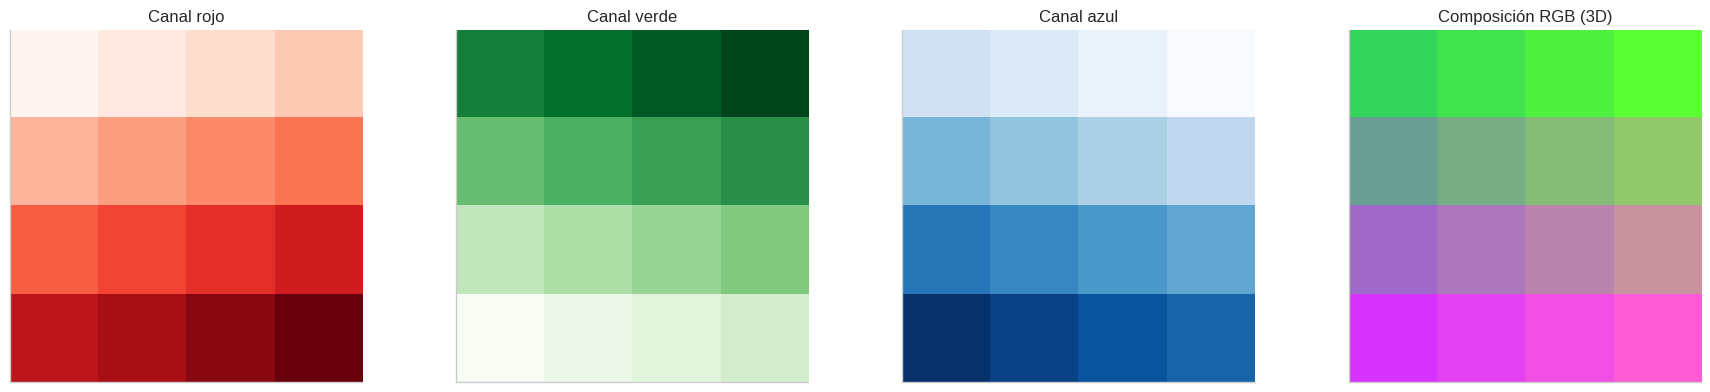

Forma de la imagen: (3, 4, 4) = (canales, alto, ancho)
Pixel en fila 1, columna 2: tensor([0.5200, 0.7333, 0.4667])


In [4]:
rgb_image = image.permute(1, 2, 0).numpy()

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
channel_names = ["Canal rojo", "Canal verde", "Canal azul"]
channel_cmaps = ["Reds", "Greens", "Blues"]

for index in range(3):
    axes[index].imshow(image[index].numpy(), cmap=channel_cmaps[index])
    axes[index].set_title(channel_names[index])
    axes[index].set_xticks([])
    axes[index].set_yticks([])

axes[3].imshow(rgb_image)
axes[3].set_title("Composición RGB (3D)")
axes[3].set_xticks([])
axes[3].set_yticks([])

plt.tight_layout()
plt.show()

print(f"Forma de la imagen: {tuple(image.shape)} = (canales, alto, ancho)")
print(f"Pixel en fila 1, columna 2: {image[:, 1, 2]}")

### PyTorch y NumPy: dos mundos muy cercanos

PyTorch y NumPy usan estructuras conceptualmente parecidas. En CPU, incluso pueden **compartir memoria**.

Eso es muy útil porque permite pasar datos de una biblioteca a otra sin copiar innecesariamente.

Las dos conversiones más frecuentes son:
- `torch.from_numpy(array_numpy)`
- `tensor_torch.numpy()`

### Demostración: conversión y memoria compartida

Cuando convertimos un arreglo de `NumPy` a un tensor con `torch.from_numpy(...)`, ambos objetos pueden apuntar a la misma memoria en CPU.

Eso significa que modificar uno puede afectar al otro. Veámoslo con un ejemplo concreto.

In [5]:
numpy_array = np.array([10.0, 20.0, 30.0], dtype=np.float32)
tensor_from_numpy = torch.from_numpy(numpy_array)
numpy_from_tensor = tensor_from_numpy.numpy()

print("Estado inicial")
print("NumPy:", numpy_array)
print("Torch:", tensor_from_numpy)
print("NumPy desde Torch:", numpy_from_tensor)

numpy_array[0] = -5.0
tensor_from_numpy[1] = 99.0

print("\nDespués de modificar ambos objetos")
print("NumPy:", numpy_array)
print("Torch:", tensor_from_numpy)
print("NumPy desde Torch:", numpy_from_tensor)

tensor_copy = torch.tensor(numpy_array)
numpy_array[2] = 123.0

print("\nUn tensor creado con torch.tensor(...) sí hace una copia:")
print("NumPy actualizado:", numpy_array)
print("Tensor copia:", tensor_copy)

Estado inicial
NumPy: [10. 20. 30.]
Torch: tensor([10., 20., 30.])
NumPy desde Torch: [10. 20. 30.]

Después de modificar ambos objetos
NumPy: [-5. 99. 30.]
Torch: tensor([-5., 99., 30.])
NumPy desde Torch: [-5. 99. 30.]

Un tensor creado con torch.tensor(...) sí hace una copia:
NumPy actualizado: [ -5.  99. 123.]
Tensor copia: tensor([-5., 99., 30.])


### Operaciones básicas: suma elemento a elemento y broadcasting

La suma elemento a elemento requiere tensores con la misma forma.

El `broadcasting` permite combinar tensores compatibles aunque no tengan exactamente la misma forma. Un caso clásico es sumar un vector de sesgos a cada fila de una matriz.

Matriz A:
tensor([[1., 2., 3.],
        [4., 5., 6.]])

Matriz B:
tensor([[6., 5., 4.],
        [3., 2., 1.]])

Vector de bias:
tensor([10., 20., 30.])
Suma elemento a elemento:
tensor([[7., 7., 7.],
        [7., 7., 7.]])

Broadcasting: sumamos un vector fila a cada fila de la matriz
tensor([[11., 22., 33.],
        [14., 25., 36.]])


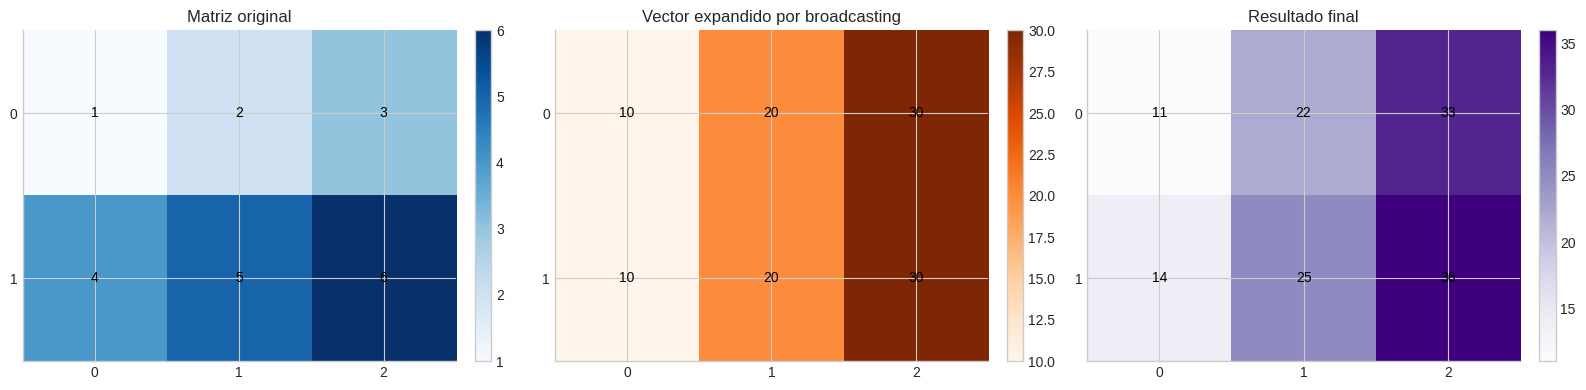

In [6]:
matrix_a = torch.tensor([[1.0, 2.0, 3.0],
                         [4.0, 5.0, 6.0]])
matrix_b = torch.tensor([[6.0, 5.0, 4.0],
                         [3.0, 2.0, 1.0]])
bias_vector = torch.tensor([10.0, 20.0, 30.0])
print("Matriz A:")
print(matrix_a)
print("\nMatriz B:")
print(matrix_b)
print("\nVector de bias:")
print(bias_vector)

elementwise_sum = matrix_a + matrix_b
broadcast_sum = matrix_a + bias_vector

print("Suma elemento a elemento:")
print(elementwise_sum)

print("\nBroadcasting: sumamos un vector fila a cada fila de la matriz")
print(broadcast_sum)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
heatmaps = [
    matrix_a.numpy(),
    bias_vector.unsqueeze(0).repeat(matrix_a.shape[0], 1).numpy(),
    broadcast_sum.numpy(),
]
titles = ["Matriz original", "Vector expandido por broadcasting", "Resultado final"]
cmaps = ["Blues", "Oranges", "Purples"]

for ax, values, title, cmap in zip(axes, heatmaps, titles, cmaps):
    image_plot = ax.imshow(values, cmap=cmap, aspect="auto")
    ax.set_title(title)
    ax.set_xticks(range(values.shape[1]))
    ax.set_yticks(range(values.shape[0]))
    for row in range(values.shape[0]):
        for col in range(values.shape[1]):
            ax.text(col, row, f"{values[row, col]:.0f}", ha="center", va="center", color="black")
    fig.colorbar(image_plot, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

### Multiplicación de matrices

Mientras que la suma elemento a elemento combina posiciones equivalentes, la multiplicación de matrices mezcla filas y columnas para producir nuevas representaciones.

Esta operación aparece constantemente en redes neuronales y capas lineales.

Forma de la matriz izquierda: (3, 2)
Forma de la matriz derecha: (2, 3)
Forma del resultado: (3, 3)

Resultado de left_matrix @ right_matrix:
tensor([[ 1.,  2.,  3.],
        [ 3.,  4.,  7.],
        [ 5.,  6., 11.]])


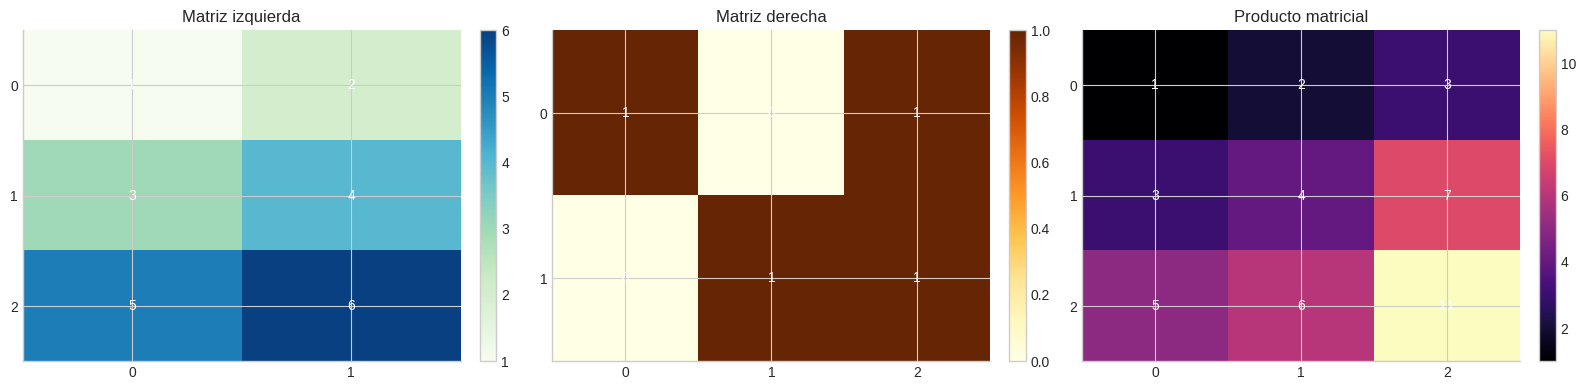

In [7]:
left_matrix = torch.tensor([[1.0, 2.0],
                            [3.0, 4.0],
                            [5.0, 6.0]])
right_matrix = torch.tensor([[1.0, 0.0, 1.0],
                             [0.0, 1.0, 1.0]])
matmul_result = left_matrix @ right_matrix

print(f"Forma de la matriz izquierda: {tuple(left_matrix.shape)}")
print(f"Forma de la matriz derecha: {tuple(right_matrix.shape)}")
print(f"Forma del resultado: {tuple(matmul_result.shape)}")

print("\nResultado de left_matrix @ right_matrix:")
print(matmul_result)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
matrices = [left_matrix.numpy(), right_matrix.numpy(), matmul_result.numpy()]
titles = ["Matriz izquierda", "Matriz derecha", "Producto matricial"]
cmaps = ["GnBu", "YlOrBr", "magma"]

for ax, values, title, cmap in zip(axes, matrices, titles, cmaps):
    image_plot = ax.imshow(values, cmap=cmap, aspect="auto")
    ax.set_title(title)
    ax.set_xticks(range(values.shape[1]))
    ax.set_yticks(range(values.shape[0]))
    for row in range(values.shape[0]):
        for col in range(values.shape[1]):
            ax.text(col, row, f"{values[row, col]:.0f}", ha="center", va="center", color="white")
    fig.colorbar(image_plot, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

### Cierre de la sección 1

Ya tenemos tres ingredientes fundamentales del lenguaje tensorial:
- dimensionalidad (`ndim`),
- forma (`shape`),
- operaciones básicas para combinar información.

In [8]:
section_1_summary = {
    "Escalar": tuple(scalar.shape) if scalar.ndim > 0 else (),
    "Vector": tuple(vector.shape),
    "Matriz": tuple(matrix.shape),
    "Imagen RGB": tuple(image.shape),
}

print("Resumen de shapes en la sección 1:")
for name, shape in section_1_summary.items():
    print(f"- {name:>10}: shape = {shape}")

Resumen de shapes en la sección 1:
-    Escalar: shape = ()
-     Vector: shape = (4,)
-     Matriz: shape = (2, 3)
- Imagen RGB: shape = (3, 4, 4)


In [9]:
print("Resumen rápido de shapes")
print(f"Escalar: ndim={scalar.ndim}, shape={()}")
print(f"Vector: ndim={vector.ndim}, shape={tuple(vector.shape)}")
print(f"Matriz: ndim={matrix.ndim}, shape={tuple(matrix.shape)}")
print(f"Imagen RGB: ndim={image.ndim}, shape={tuple(image.shape)}")

print("\nOperaciones vistas:")
print(f"Suma elemento a elemento -> {tuple(elementwise_sum.shape)}")
print(f"Broadcasting -> {tuple(broadcast_sum.shape)}")
print(f"Producto matricial -> {tuple(matmul_result.shape)}")

Resumen rápido de shapes
Escalar: ndim=0, shape=()
Vector: ndim=1, shape=(4,)
Matriz: ndim=2, shape=(2, 3)
Imagen RGB: ndim=3, shape=(3, 4, 4)

Operaciones vistas:
Suma elemento a elemento -> (2, 3)
Broadcasting -> (2, 3)
Producto matricial -> (3, 3)


## 2. Autograd & Modeling

Una gran ventaja de PyTorch es que puede construir un **grafo computacional** mientras hacemos operaciones y luego usarlo para calcular gradientes automáticamente.

En entrenamiento, esta idea es clave: si podemos calcular derivadas, entonces podemos ajustar parámetros para minimizar una función de pérdida.

In [10]:
x = torch.tensor(2.0, requires_grad=True)

quadratic_term = 3 * x**2
linear_term = 2 * x
f_x = quadratic_term + linear_term

print(f"x = {x.item()}")
print(f"Término cuadrático: {quadratic_term.item()}")
print(f"Término lineal: {linear_term.item()}")
print(f"f(x) = 3x^2 + 2x = {f_x.item()}")
print(f"grad_fn de f(x): {f_x.grad_fn}")

f_x.backward()

print(f"Gradiente calculado por Autograd en x = 2: {x.grad.item()}")

x = 2.0
Término cuadrático: 12.0
Término lineal: 4.0
f(x) = 3x^2 + 2x = 16.0
grad_fn de f(x): <AddBackward0 object at 0x7f9bd0c45ae0>
Gradiente calculado por Autograd en x = 2: 14.0


### Intuición del grafo computacional

Cada operación sobre un tensor con `requires_grad=True` queda registrada como parte de una cadena de transformaciones.

Luego, `backward()` recorre esa cadena en sentido inverso y aplica la regla de la cadena para obtener derivadas.

In [11]:
def analytical_derivative(x_value):
    return 6 * x_value + 2

expected_gradient = analytical_derivative(x.item())

print(f"Derivada analítica en x = {x.item():.1f}: {expected_gradient:.1f}")
print(f"Derivada por Autograd en x = {x.item():.1f}: {x.grad.item():.1f}")
print(f"¿Coinciden? {'Sí' if np.isclose(expected_gradient, x.grad.item()) else 'No'}")

Derivada analítica en x = 2.0: 14.0
Derivada por Autograd en x = 2.0: 14.0
¿Coinciden? Sí


### Visualización: parábola y recta tangente

La recta tangente en un punto resume la pendiente local de la función. Esa pendiente es, precisamente, el gradiente que `Autograd` acaba de calcular.

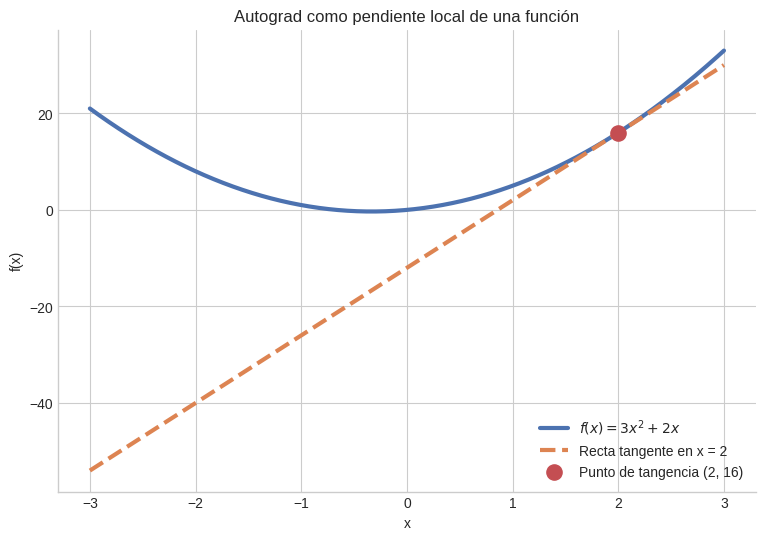

Pendiente de la tangente en x = 2: 14.0


In [12]:
x_values = torch.linspace(-3, 3, 400)
y_values = 3 * x_values**2 + 2 * x_values

x0 = x.detach().item()
y0 = f_x.detach().item()
slope = x.grad.item()
tangent_line = y0 + slope * (x_values - x0)

plt.figure(figsize=(9, 6))
plt.plot(x_values.numpy(), y_values.numpy(), label=r"$f(x)=3x^2+2x$", linewidth=3, color="#4C72B0")
plt.plot(x_values.numpy(), tangent_line.detach().numpy(), label="Recta tangente en x = 2", linewidth=3, linestyle="--", color="#DD8452")
plt.scatter([x0], [y0], color="#C44E52", s=120, zorder=5, label=f"Punto de tangencia ({x0:.0f}, {y0:.0f})")
plt.title("Autograd como pendiente local de una función")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.show()

print(f"Pendiente de la tangente en x = 2: {slope}")

La lectura geométrica es muy valiosa: el gradiente nos dice **qué tan inclinada está la función localmente**.

En optimización, esa pendiente nos sirve para decidir hacia dónde mover los parámetros para disminuir la pérdida.

In [13]:
analytical_gradient = 6 * x0 + 2

print(f"Gradiente por fórmula analítica: {analytical_gradient:.1f}")
print(f"Gradiente por Autograd: {x.grad.item():.1f}")
print(f"¿Coinciden? {'Sí' if np.isclose(analytical_gradient, x.grad.item()) else 'No'}")

sample_points = torch.tensor([-2.0, -1.0, 0.0, 1.0, 2.0])
sample_gradients = 6 * sample_points + 2

for point, gradient in zip(sample_points, sample_gradients):
    print(f"x = {point.item():>4.1f} -> f'(x) = {gradient.item():>4.1f}")

Gradiente por fórmula analítica: 14.0
Gradiente por Autograd: 14.0
¿Coinciden? Sí
x = -2.0 -> f'(x) = -10.0
x = -1.0 -> f'(x) = -4.0
x =  0.0 -> f'(x) =  2.0
x =  1.0 -> f'(x) =  8.0
x =  2.0 -> f'(x) = 14.0


## 3. Data Loading & Single Neuron (Perceptrón)

Ahora conectamos los conceptos anteriores con un flujo de trabajo típico de Deep Learning:
1. Crear datos.
2. Organizarlos en un `Dataset`.
3. Pedir lotes con un `DataLoader`.
4. Definir un modelo entrenable.
5. Optimizar sus parámetros con gradientes.

### Paso 1: crear un conjunto de datos sintético

Vamos a generar datos de una recta con ruido. Esta es una situación ideal para una neurona lineal:

$$y \approx wx + b$$

Así podremos visualizar fácilmente si el modelo aprende la pendiente y la ordenada al origen correctas.

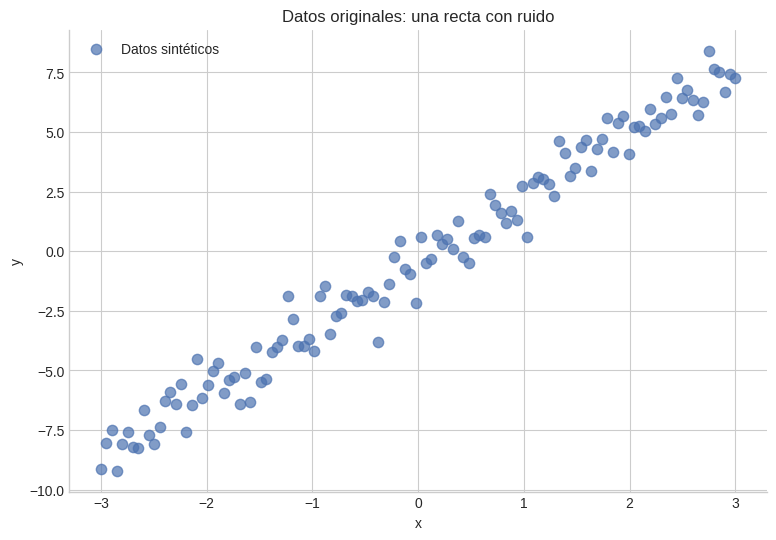

Forma de features: (120, 1)
Forma de targets: (120, 1)


In [14]:
true_weight = 2.7
true_bias = -0.4
num_samples = 120

features = torch.linspace(-3, 3, num_samples).unsqueeze(1)
noise = 0.8 * torch.randn_like(features)
targets = true_weight * features + true_bias + noise

plt.figure(figsize=(9, 6))
plt.scatter(features.numpy(), targets.numpy(), alpha=0.7, s=55, color="#4C72B0", label="Datos sintéticos")
plt.title("Datos originales: una recta con ruido")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

print(f"Forma de features: {tuple(features.shape)}")
print(f"Forma de targets: {tuple(targets.shape)}")

In [15]:
class SyntheticRegressionDataset(Dataset):
    def __init__(self, features, targets):
        self.features = features.float()
        self.targets = targets.float()

    def __len__(self):
        return len(self.features)

    def __getitem__(self, index):
        return self.features[index], self.targets[index]

dataset = SyntheticRegressionDataset(features, targets)
batch_size = 16
train_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

batch_features, batch_targets = next(iter(train_loader))

print(f"Cantidad total de ejemplos: {len(dataset)}")
print(f"Batch size: {batch_size}")
print(f"Forma de un batch de entrada: {tuple(batch_features.shape)}")
print(f"Forma de un batch de salida: {tuple(batch_targets.shape)}")

print("\nPrimeros 5 ejemplos del batch:")
for input_value, target_value in zip(batch_features[:5], batch_targets[:5]):
    print(f"x = {input_value.item():>5.2f} -> y = {target_value.item():>6.2f}")

Cantidad total de ejemplos: 120
Batch size: 16
Forma de un batch de entrada: (16, 1)
Forma de un batch de salida: (16, 1)

Primeros 5 ejemplos del batch:
x = -0.03 -> y =  -2.15
x = -1.49 -> y =  -5.47
x = -1.94 -> y =  -5.02
x =  2.34 -> y =   6.47
x =  1.44 -> y =   3.16


### Paso 2: `Dataset` y `DataLoader`

- Un `Dataset` define cómo obtener un ejemplo.
- Un `DataLoader` agrupa ejemplos en lotes y puede mezclarlos automáticamente.

Esta separación es muy útil porque desacopla los datos del proceso de entrenamiento.

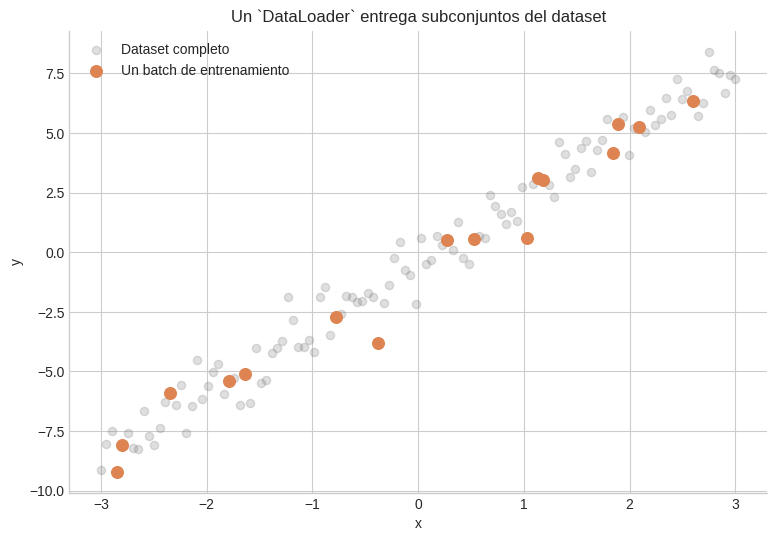

In [16]:
example_batch_features, example_batch_targets = next(iter(train_loader))

plt.figure(figsize=(9, 6))
plt.scatter(features.numpy(), targets.numpy(), alpha=0.25, s=35, color="gray", label="Dataset completo")
plt.scatter(
    example_batch_features.numpy(),
    example_batch_targets.numpy(),
    s=70,
    color="#DD8452",
    label="Un batch de entrenamiento",
)
plt.title("Un `DataLoader` entrega subconjuntos del dataset")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

### Paso 3: una neurona lineal

Una neurona lineal implementa una transformación muy simple pero poderosa:

$$\hat{y} = wx + b$$

Si el problema realmente tiene una relación aproximadamente lineal, este modelo debería aprenderla con facilidad.

In [17]:
class SingleNeuron(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(in_features=1, out_features=1)

    def forward(self, inputs):
        return self.linear(inputs)

model = SingleNeuron()
print(model)

initial_weight = model.linear.weight.item()
initial_bias = model.linear.bias.item()
print(f"\nPeso inicial: {initial_weight:.4f}")
print(f"Bias inicial: {initial_bias:.4f}")

with torch.no_grad():
    initial_predictions = model(features[:5])

print("\nPredicciones iniciales para los primeros 5 puntos:")
for feature_value, prediction_value in zip(features[:5], initial_predictions):
    print(f"x = {feature_value.item():>5.2f} -> y_pred = {prediction_value.item():>7.3f}")

SingleNeuron(
  (linear): Linear(in_features=1, out_features=1, bias=True)
)

Peso inicial: -0.9284
Bias inicial: -0.7012

Predicciones iniciales para los primeros 5 puntos:
x = -3.00 -> y_pred =   2.084
x = -2.95 -> y_pred =   2.037
x = -2.90 -> y_pred =   1.990
x = -2.85 -> y_pred =   1.943
x = -2.80 -> y_pred =   1.897


### Paso 4: función de pérdida y optimizador

Para regresión, una elección natural es el error cuadrático medio (`MSELoss`).

El optimizador `SGD` actualiza los parámetros siguiendo la dirección opuesta al gradiente.

In [18]:
loss_function = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.03)
num_epochs = 120

loss_history = []
weight_history = []
bias_history = []

for epoch in range(num_epochs):
    for batch_features, batch_targets in train_loader:
        predictions = model(batch_features)
        loss = loss_function(predictions, batch_targets)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    with torch.no_grad():
        full_predictions = model(features)
        epoch_loss = loss_function(full_predictions, targets).item()
        current_weight = model.linear.weight.item()
        current_bias = model.linear.bias.item()

    loss_history.append(epoch_loss)
    weight_history.append(current_weight)
    bias_history.append(current_bias)

    if epoch in {0, 1, 2, 4, 9, 24, 59, 119}:
        print(
            f"Época {epoch + 1:>3} | loss = {epoch_loss:>8.4f} | "
            f"w = {current_weight:>6.3f} | b = {current_bias:>6.3f}"
        )

Época   1 | loss =   2.2154 | w =  2.004 | b = -0.662
Época   2 | loss =   0.6234 | w =  2.616 | b = -0.604
Época   3 | loss =   0.5723 | w =  2.697 | b = -0.537
Época   5 | loss =   0.5645 | w =  2.738 | b = -0.498
Época  10 | loss =   0.5648 | w =  2.710 | b = -0.485
Época  25 | loss =   0.5638 | w =  2.715 | b = -0.455
Época  60 | loss =   0.5634 | w =  2.736 | b = -0.479
Época 120 | loss =   0.5636 | w =  2.741 | b = -0.445


### Paso 4: observar cómo aprende el modelo

Si todo va bien, la pérdida debería bajar época tras época. Eso indica que la neurona está encontrando parámetros cada vez mejores para aproximar la relación entre `x` e `y`.

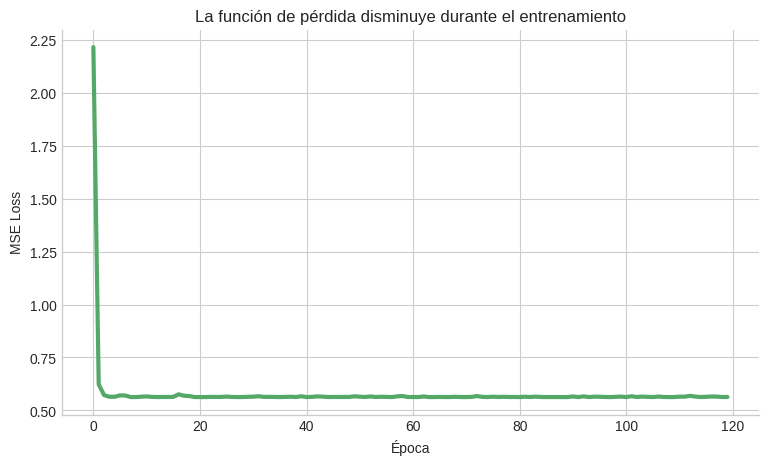

Loss inicial: 2.2154
Loss final: 0.5636


In [19]:
plt.figure(figsize=(9, 5))
plt.plot(loss_history, linewidth=3, color="#55A868")
plt.title("La función de pérdida disminuye durante el entrenamiento")
plt.xlabel("Época")
plt.ylabel("MSE Loss")
plt.show()

print(f"Loss inicial: {loss_history[0]:.4f}")
print(f"Loss final: {loss_history[-1]:.4f}")

### ¿Qué aprendió la neurona?

Si el entrenamiento funcionó, la recta predicha por el modelo debería acercarse mucho a la tendencia general de los datos.

Vamos a compararla contra:
- los puntos originales,
- la recta verdadera que usamos para generar los datos,
- la recta aprendida por la neurona.

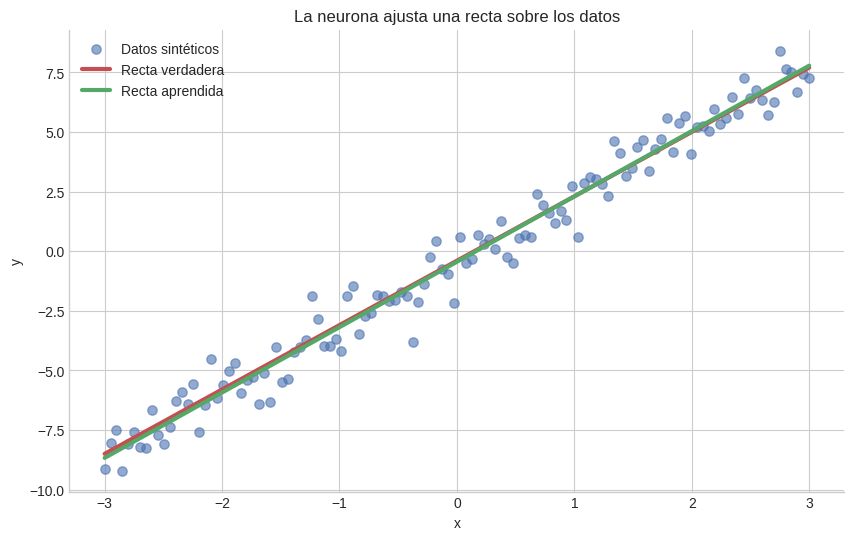

In [20]:
with torch.no_grad():
    learned_predictions = model(features)

sorted_indices = torch.argsort(features[:, 0])
sorted_features = features[sorted_indices]
sorted_predictions = learned_predictions[sorted_indices]
sorted_targets = targets[sorted_indices]
true_line = true_weight * sorted_features + true_bias

plt.figure(figsize=(10, 6))
plt.scatter(features.numpy(), targets.numpy(), alpha=0.6, s=45, color="#4C72B0", label="Datos sintéticos")
plt.plot(sorted_features.numpy(), true_line.numpy(), linewidth=3, color="#C44E52", label="Recta verdadera")
plt.plot(sorted_features.numpy(), sorted_predictions.numpy(), linewidth=3, color="#55A868", label="Recta aprendida")
plt.title("La neurona ajusta una recta sobre los datos")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

### Interpretar parámetros y predicciones

En un modelo lineal simple, los parámetros aprendidos tienen interpretación directa:
- `weight` ≈ pendiente de la recta,
- `bias` ≈ ordenada al origen.

Eso hace que este ejemplo sea excelente para unir intuición geométrica, optimización y modelado.

In [21]:
learned_weight = model.linear.weight.item()
learned_bias = model.linear.bias.item()

print(f"Parámetro verdadero w: {true_weight:.3f}")
print(f"Parámetro aprendido w: {learned_weight:.3f}")
print(f"Parámetro verdadero b: {true_bias:.3f}")
print(f"Parámetro aprendido b: {learned_bias:.3f}")

test_inputs = torch.tensor([[-2.0], [0.0], [2.0]])
with torch.no_grad():
    test_outputs = model(test_inputs)

print("\nPredicciones del modelo:")
for input_value, output_value in zip(test_inputs, test_outputs):
    print(f"x = {input_value.item():>4.1f} -> y_pred = {output_value.item():>6.2f}")

Parámetro verdadero w: 2.700
Parámetro aprendido w: 2.741
Parámetro verdadero b: -0.400
Parámetro aprendido b: -0.445

Predicciones del modelo:
x = -2.0 -> y_pred =  -5.93
x =  0.0 -> y_pred =  -0.45
x =  2.0 -> y_pred =   5.04


In [22]:
weight_error = abs(learned_weight - true_weight)
bias_error = abs(learned_bias - true_bias)

print(f"Error absoluto en el peso: {weight_error:.4f}")
print(f"Error absoluto en el bias: {bias_error:.4f}")

Error absoluto en el peso: 0.0415
Error absoluto en el bias: 0.0452


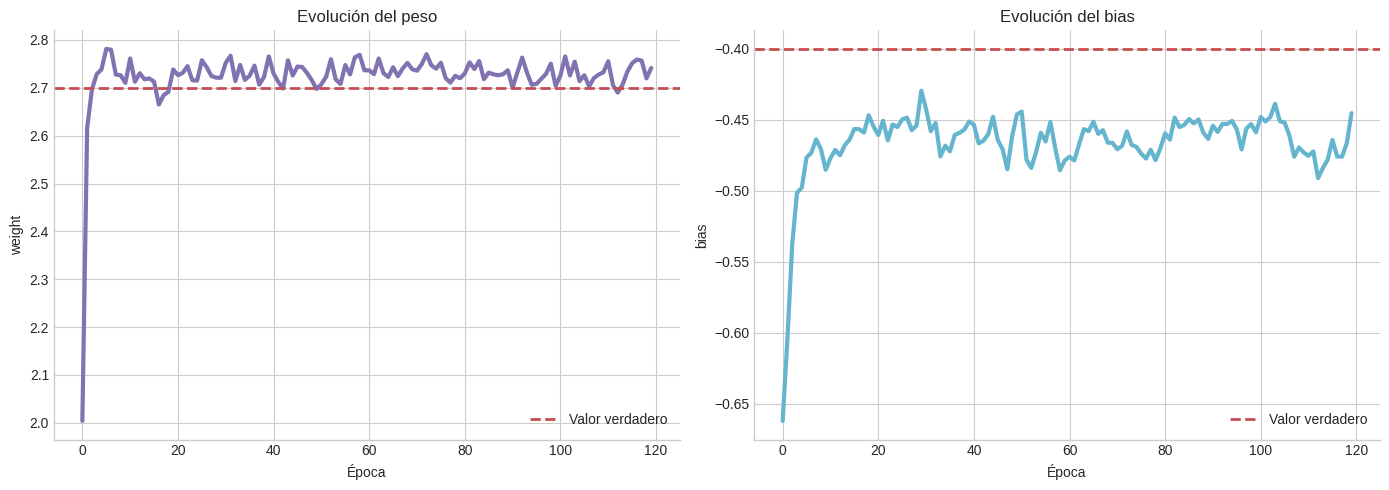

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(weight_history, linewidth=3, color="#8172B2")
axes[0].axhline(true_weight, color="#C44E52", linestyle="--", linewidth=2, label="Valor verdadero")
axes[0].set_title("Evolución del peso")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("weight")
axes[0].legend()

axes[1].plot(bias_history, linewidth=3, color="#64B5CD")
axes[1].axhline(true_bias, color="#C44E52", linestyle="--", linewidth=2, label="Valor verdadero")
axes[1].set_title("Evolución del bias")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("bias")
axes[1].legend()

plt.tight_layout()
plt.show()

In [25]:
for batch_index, (batch_features, batch_targets) in enumerate(train_loader):
    print(
        f"Lote {batch_index + 1:>2} | "
        f"features shape = {tuple(batch_features.shape)} | "
        f"targets shape = {tuple(batch_targets.shape)}"
    )
    if batch_index == 2:
        break

Lote  1 | features shape = (16, 1) | targets shape = (16, 1)
Lote  2 | features shape = (16, 1) | targets shape = (16, 1)
Lote  3 | features shape = (16, 1) | targets shape = (16, 1)


## Resumen final

En este notebook recorrimos un camino completo y muy cercano a un flujo real de trabajo en Deep Learning:

### 1. Tensores
- Vimos ejemplos desde 0D hasta 3D.
- Interpretamos `shape` y `ndim` como herramientas para leer datos.
- Practicamos suma elemento a elemento, broadcasting y producto matricial.

### 2. Autograd
- Construimos la función $f(x)=3x^2+2x$.
- Calculamos su derivada en $x=2$ con `requires_grad=True` y `backward()`.
- Visualizamos la recta tangente para conectar gradiente con intuición geométrica.

### 3. Dataset, DataLoader y una neurona
- Generamos datos sintéticos.
- Armamos un `Dataset` y un `DataLoader` con `batch_size`.
- Definimos una clase `SingleNeuron` basada en `nn.Linear`.
- Entrenamos con el patrón clásico: `zero_grad()`, `backward()`, `step()`.
- Observamos cómo baja la pérdida y cómo la recta aprendida se ajusta a los datos.

**Idea para llevarse de esta práctica:** detrás de modelos más grandes siguen apareciendo las mismas piezas fundamentales: tensores, gradientes, lotes de datos y parámetros que se actualizan para minimizar una pérdida.

En el próximo notebook podremos reutilizar esta base para construir modelos más expresivos.